# Supervised Learning - SVM

<h5 style="font-size:14px;">
<b>Definition:</b> Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression tasks. The main idea of SVM is to find an optimal hyperplane that best separates data points belonging to different classes.

<b>Working Principle:</b><br>
SVM identifies the decision boundary that maximizes the margin between classes. The margin represents the distance between the hyperplane and the nearest data points from each class, called support vectors.

The algorithm focuses on maximizing this margin to improve generalization performance.

<b>Theoretical Concepts:</b><br>
- <b>Hyperplane</b> – a decision boundary that separates classes in feature space.<br>
- <b>Support Vectors</b> – data points closest to the hyperplane that influence its position.<br>
- <b>Kernel Function</b> – transforms data into higher-dimensional space to handle non-linear classification.

<b>Common Kernel Functions:</b><br>
- Linear Kernel – used for linearly separable data.<br>
- Radial Basis Function (RBF) Kernel – used for non-linear relationships.<br>
- Polynomial Kernel – captures polynomial relationships between features.

<b>Advantages:</b><br>
- Effective in high-dimensional spaces.<br>
- Works well with complex decision boundaries.<br>
- Good generalization capability.

<b>Limitations:</b><br>
- Sensitive to parameter selection.<br>
- Computationally expensive for large datasets.<br>
- Requires feature scaling.

<b>Main Parameters Used:</b><br>
- Kernel type.<br>
- Regularization parameter (C).<br>
- Gamma parameter (for RBF kernel).
</h5>

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

## Dataset Description – Breast Cancer Dataset

The dataset used in this project comes from the Kaggle platform and contains information about patients diagnosed with breast cancer. The objective is to classify the patient’s status based on clinical and tumor-related characteristics.

### Demographic and Clinical Features

- **Age** – the age of the patient.
- **Race** – the patient's race (e.g., White, Other).
- **Marital Status** – the patient's marital status (e.g., Married, Single).
- **T Stage** – classification of the primary tumor according to its size and extent.
- **N Stage** – indicates whether lymph nodes are affected.
- **6th Stage** – the clinical stage of the cancer according to medical classification.
- **Differentiate** – the degree of cellular differentiation, which shows how much the tumor cells resemble normal cells.

- **Grade** – the histological grade of the tumor, indicating the aggressiveness of the cancer:
  - Grade 1 – less aggressive tumor
  - Grade 2 – moderately aggressive tumor
  - Grade 3 – highly aggressive tumor

- **A Stage** – shows the extent of the neoplasm:
  - Regional – local spread
  - Distant – metastasis to distant organs

- **Tumor Size** – the size of the tumor measured in millimeters.
- **Estrogen Status** – indicates the presence or absence of estrogen receptors.
- **Progesterone Status** – indicates the status of progesterone receptors.
- **Regional Node Examined** – the number of lymph nodes examined.
- **Regional Node Positive** – the number of lymph nodes with confirmed metastasis.

### Target Variable

- **Status** – the variable to be classified:
  - Alive
  - Dead

In [70]:
data = pd.read_csv("../data/Breast_Cancer.csv")

In [71]:
data.head(10)

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive
5,51,White,Single,T1,N1,IIA,Moderately differentiated,2,Regional,20,Positive,Positive,18,2,89,Alive
6,51,White,Married,T1,N1,IIA,Well differentiated,1,Regional,8,Positive,Positive,11,1,54,Alive
7,40,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,30,Positive,Positive,9,1,14,Dead
8,40,White,Divorced,T4,N3,IIIC,Poorly differentiated,3,Regional,103,Positive,Positive,20,18,70,Alive
9,69,White,Married,T4,N3,IIIC,Well differentiated,1,Distant,32,Positive,Positive,21,12,92,Alive


In [72]:
data.tail(10)

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
4014,40,White,Married,T3,N1,IIIA,Moderately differentiated,2,Regional,68,Positive,Positive,22,2,86,Alive
4015,65,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,40,Positive,Positive,4,4,68,Alive
4016,54,White,Married,T2,N1,IIB,Well differentiated,1,Regional,50,Positive,Positive,29,2,52,Alive
4017,46,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,28,Negative,Negative,2,1,19,Dead
4018,64,White,Married,T1,N1,IIA,Moderately differentiated,2,Regional,10,Positive,Positive,11,1,70,Alive
4019,62,Other,Married,T1,N1,IIA,Moderately differentiated,2,Regional,9,Positive,Positive,1,1,49,Alive
4020,56,White,Divorced,T2,N2,IIIA,Moderately differentiated,2,Regional,46,Positive,Positive,14,8,69,Alive
4021,68,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,22,Positive,Negative,11,3,69,Alive
4022,58,Black,Divorced,T2,N1,IIB,Moderately differentiated,2,Regional,44,Positive,Positive,11,1,72,Alive
4023,46,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,30,Positive,Positive,7,2,100,Alive


In [73]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     4024 non-null   int64
 1   Race                    4024 non-null   str  
 2   Marital Status          4024 non-null   str  
 3   T Stage                 4024 non-null   str  
 4   N Stage                 4024 non-null   str  
 5   6th Stage               4024 non-null   str  
 6   differentiate           4024 non-null   str  
 7   Grade                   4024 non-null   str  
 8   A Stage                 4024 non-null   str  
 9   Tumor Size              4024 non-null   int64
 10  Estrogen Status         4024 non-null   str  
 11  Progesterone Status     4024 non-null   str  
 12  Regional Node Examined  4024 non-null   int64
 13  Reginol Node Positive   4024 non-null   int64
 14  Survival Months         4024 non-null   int64
 15  Status                  4024 non

In [74]:
data.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [75]:
data.columns

Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='str')

In [76]:
data.shape

(4024, 16)

In [77]:
data.dtypes

Age                       int64
Race                        str
Marital Status              str
T Stage                     str
N Stage                     str
6th Stage                   str
differentiate               str
Grade                       str
A Stage                     str
Tumor Size                int64
Estrogen Status             str
Progesterone Status         str
Regional Node Examined    int64
Reginol Node Positive     int64
Survival Months           int64
Status                      str
dtype: object

In [78]:
data.isnull().sum()

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

In [79]:
data.duplicated().sum()

np.int64(1)

In [80]:
data.nunique()

Age                        40
Race                        3
Marital Status              5
T Stage                     4
N Stage                     3
6th Stage                   5
differentiate               4
Grade                       4
A Stage                     2
Tumor Size                110
Estrogen Status             2
Progesterone Status         2
Regional Node Examined     54
Reginol Node Positive      38
Survival Months           107
Status                      2
dtype: int64

<Axes: >

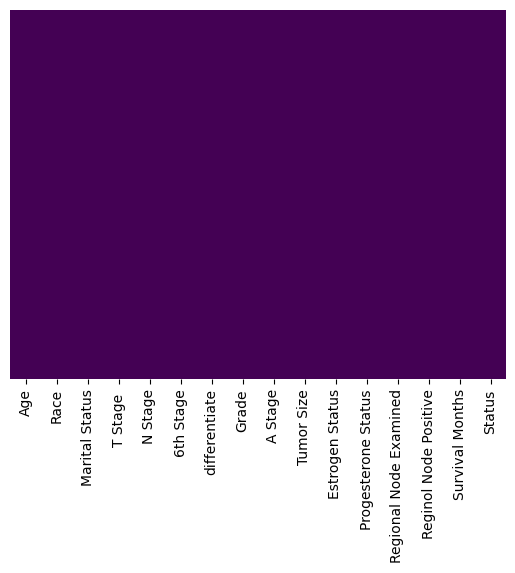

In [81]:
sns.heatmap(data.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [82]:
data = pd.read_csv("../data/Breast_Cancer.csv")

categorical_cols = [
    'Race', 'Marital Status', 'T Stage ', 'N Stage',
    '6th Stage', 'differentiate', 'Grade', 'A Stage',
    'Estrogen Status', 'Progesterone Status', 'Status'
]

le = LabelEncoder()

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [83]:
data.head(5)

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,2,1,0,0,0,1,3,1,4,1,1,24,1,60,0
1,50,2,1,1,1,2,0,2,1,35,1,1,14,5,62,0
2,58,2,0,2,2,4,0,2,1,63,1,1,14,7,75,0
3,58,2,1,0,0,0,1,3,1,18,1,1,2,1,84,0
4,47,2,1,1,0,1,1,3,1,41,1,1,3,1,50,0


In [84]:
X = data.drop("Status", axis = 1)
y = data["Status"]

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [87]:
model = SVC()
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [88]:
y_pred = model.predict(X_test)

In [89]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8993788819875776


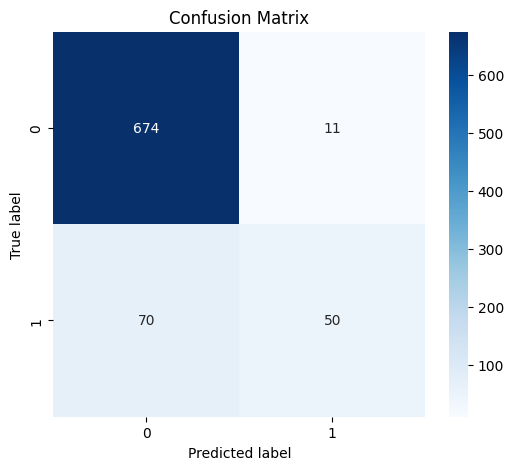

In [90]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

In [91]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       685
           1       0.82      0.42      0.55       120

    accuracy                           0.90       805
   macro avg       0.86      0.70      0.75       805
weighted avg       0.89      0.90      0.89       805



In [92]:
new_patient = [
    45,   # Age
    0,    # Race (ex: White → 0 după LabelEncoder)
    1,    # Marital Status (ex: Married → 1)
    2,    # T Stage
    1,    # N Stage
    2,    # 6th Stage
    1,    # differentiate
    2,    # Grade
    0,    # A Stage (Regional → 0)
    35,   # Tumor Size (mm)
    1,    # Estrogen Status (Positive → 1)
    1,    # Progesterone Status (Positive → 1)
    5,    # Regional Node Examined
    2,    # Reginol Node Positive
    60    # Survival Months
]

In [95]:
model = SVC(kernel='rbf', probability=True, random_state=42)

model.fit(X_train, y_train)

new_patient_df = pd.DataFrame([new_patient], columns=X.columns)

new_patient_scaled = scaler.transform(new_patient_df)

prediction = model.predict(new_patient_scaled)
probability = model.predict_proba(new_patient_scaled)

if prediction[0] == 1:
    print("\nResult: MALIGNANT tumor")
else:
    print("\nResult: BENIGN tumor")

print("Probabilities:", probability)


Result: BENIGN tumor
Probabilities: [[0.59847005 0.40152995]]
